# Setup

In [2]:
#research23_1
#conda install -c conda-forge scanpy
#conda install -c conda-forge jupyterlab
#conda remove --force numpy, scipy
#pip install numpy
#pip install scipy
#pip install seaborn numpy scipy
###### Matplotlib at 3.7 is incompatible with scanpy
###### https://discourse.scverse.org/t/metaclass-conflict-from-trying-to-import-scanpy/1133
# installed a lower version of matplotlib and error fixed.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import sys
from statsmodels import robust
import matplotlib.pyplot as plt
import os.path
import anndata as ad
import seaborn as sns
import matplotlib as mpl
import os
import harmonypy
# import scvi

sc.set_figure_params(scanpy=True, dpi=80, dpi_save=150)
pd.set_option('display.max_columns', None)


In [2]:
os.chdir("C:\\Users\\sambe\\OneDrive - Newcastle University\\Research projects\\python")
bigdata = 'C:\\Users\\sambe\\Documents\\bigdata\\'
figures = "C:\\Users\\sambe\\OneDrive - Newcastle University\\Research projects\\python\\figures"
datas = "C:\\Users\\sambe\\OneDrive - Newcastle University\\Research projects\\python\\data"
writes = "C:\\Users\\sambe\\OneDrive - Newcastle University\\Research projects\\python\\write"
os.getcwd()

'C:\\Users\\sambe\\OneDrive - Newcastle University\\Research projects\\python'

In [3]:
pan_immune_bcells = sc.read(bigdata + 'pan_immune_bcells.h5ad')
display(pan_immune_bcells)
#pan_immune_pcells = sc.read(bigdata + "pan_immune_pcells.h5ad")
#display(pan_immune_pcells)
#pan_stroma_cells  = sc.read(bigdata + "pan_stroma_cells.h5ad")
#display(pan_stroma_cells)


AnnData object with n_obs × n_vars = 63942 × 33538
    obs: 'n_counts', 'n_genes', 'file', 'mito', 'doublet_scores', 'predicted_doublets', 'old_annotation_uniform', 'organ', 'Sort_id', 'age', 'method', 'donor', 'sex', 'Sample', 'scvi_clusters', 'is_maternal_contaminant', 'anno_lvl_2_final_clean', 'celltype_annotation'
    var: 'GeneID', 'GeneName', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'scvi_model_var'

# preprocessing

##### ambient RNA, doublets, and mitocondrial

In [5]:
pan_immune_bcells.obs["age"].unique()

array([12, 14,  4, 11, 16, 15, 17,  7,  9,  8, 10], dtype=int64)

In [6]:
sc.pp.calculate_qc_metrics(pan_immune_bcells)

(                                 n_genes_by_counts  log1p_n_genes_by_counts  \
 index                                                                         
 FCAImmP7579224-CTAATGGCACTGTGTA               5492                 8.611230   
 FCAImmP7579224-TCTTTCCCAAGCCGTC               5176                 8.551981   
 FCAImmP7579224-GTATCTTAGCGACGTA               4845                 8.485909   
 FCAImmP7579224-CCCAATCAGCCACGCT               3813                 8.246434   
 FCAImmP7579224-GGAATAATCAGGTAAA               4007                 8.296048   
 ...                                            ...                      ...   
 FCAImmP7277565-TAGTTGGTCTCTGTCG                928                 6.834109   
 FCAImmP7277565-CAGGTGCAGACGCAAC                885                 6.786717   
 FCAImmP7277565-GTGCAGCAGAGCTGGT               1005                 6.913737   
 FCAImmP7277565-TACTCGCCACGTCTCT                994                 6.902743   
 FCAImmP7277565-GAACATCGTACCAGTT        

In [7]:
sc.pp.filter_cells(pan_immune_bcells, min_genes=200)
sc.pp.filter_genes(pan_immune_bcells, min_cells=3)
# doesn't seem to do anything as the cells are already cut.

In [8]:
pan_immune_bcells.var['mt'] = pan_immune_bcells.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(pan_immune_bcells, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)


In [9]:
sc.pp.normalize_total(pan_immune_bcells, target_sum=1e4)


In [10]:
sc.pp.log1p(pan_immune_bcells)


In [11]:
sc.pp.highly_variable_genes(pan_immune_bcells, min_mean=0.0125, max_mean=3, min_disp=0.5)

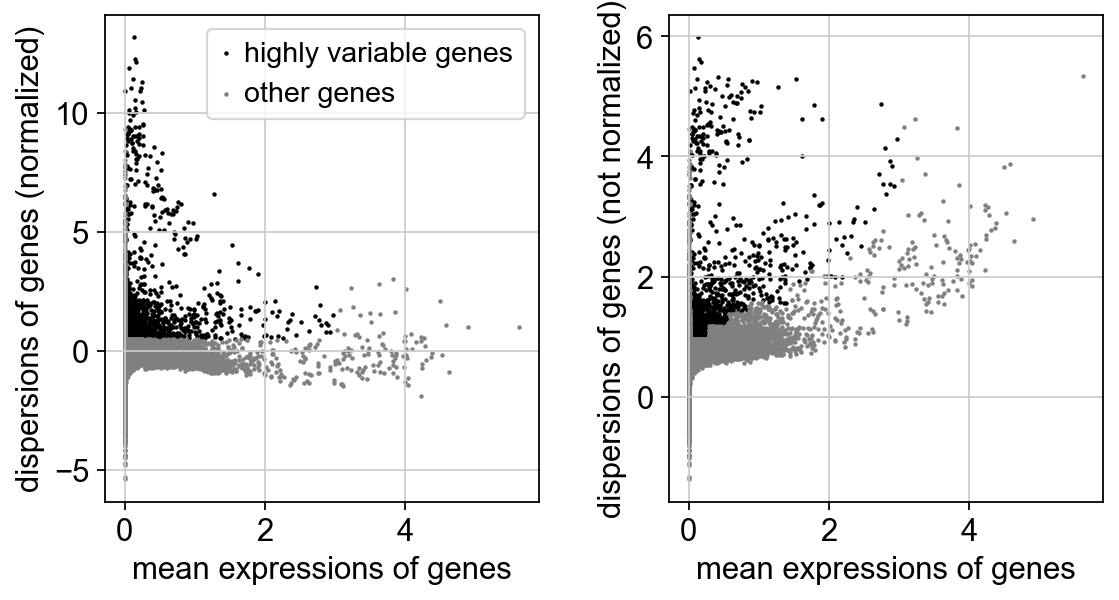

In [12]:
sc.pl.highly_variable_genes(pan_immune_bcells)
# This displays highly variable genes through calculating mean expression and dispersion measure, which is variance/mean. 
# After this the genes are split into bins based on average expression, then z-normalized the dispersion measure in each bin seperately to identify...
# the genes that were highly variable even within a group of genes with similar expression levels.(https://www.nature.com/articles/nbt.3192)

In [13]:
pan_immune_bcells.raw = pan_immune_bcells
# creating a raw dataset allows you to refer back to a dataset that has not been 

In [14]:
pan_immune_bcells = pan_immune_bcells[:, pan_immune_bcells.var.highly_variable]
#removes all but the highly variable genes selected in the "sc.pl.highly_variable_genes(pan_immune_bcells)" code;

In [15]:
sc.pp.regress_out(pan_immune_bcells, ['total_counts', 'pct_counts_mt'])
# Simone says its to remove batch effects and technical effects without directly slicing out the data.

In [16]:
sc.pp.scale(pan_immune_bcells, max_value=10)
# This function sets the mean of all the data to 0 and cuts data with a standard deviation of greater than 10. This allows data to be compared to itself.
# A look at the .obs and .var files suggests no genes or cells get cut in our data.

In [17]:
sc.tl.pca(pan_immune_bcells, svd_solver='arpack')
#dimensionality reduction to view the data.
# an SVD solver is described by this link: 
# https://towardsdatascience.com/pca-and-svd-explained-with-numpy-5d13b0d2a4d8#:~:text=SVD%20is%20another%20decomposition%20method,of%20SVD%2C%20modified%20from%20source.

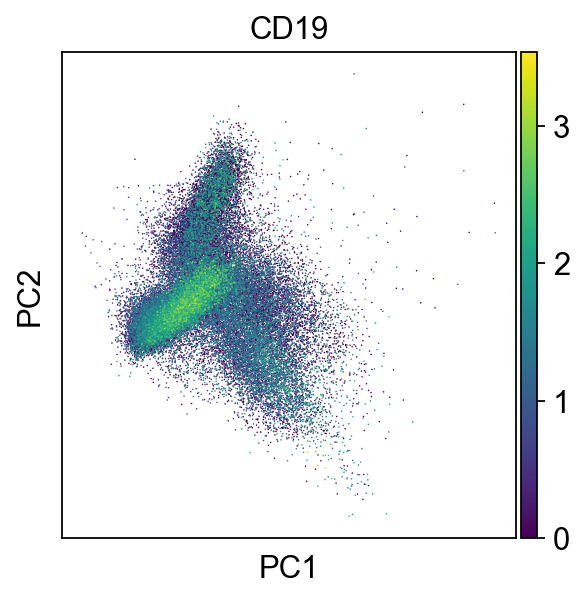

In [18]:
sc.pl.pca(pan_immune_bcells, color='CD19')
# the actual plot, plotted to CST3 gene

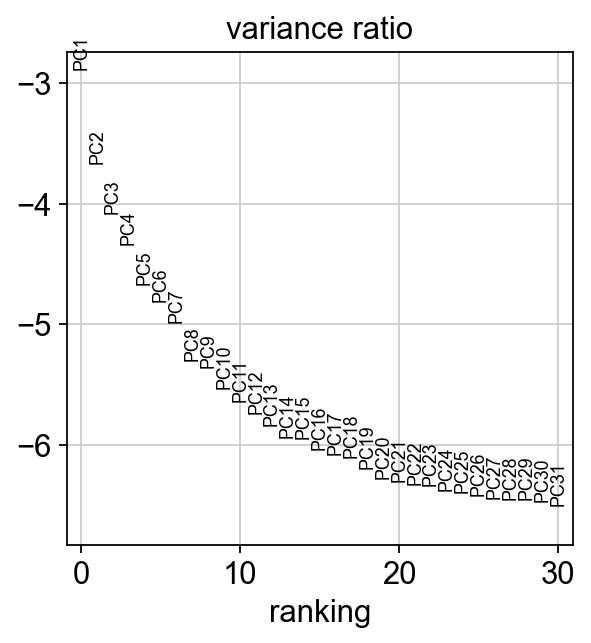

In [19]:
sc.pl.pca_variance_ratio(pan_immune_bcells, log=True)


### Batch correction

In [20]:
pan_immune_bcells_harm = pan_immune_bcells
# producing a second anndata object for harmony batch correction without altering original.

In [21]:
#sc.external.pp.harmony_integrate(pan_immune_bcells_harm, 'method')


### Nearest Neighbours

In [22]:
sc.pp.neighbors(pan_immune_bcells_harm, n_neighbors=10, n_pcs=40, use_rep='X_pca')
#, n_neighbors=10, n_pcs=40,

In [23]:
sc.tl.umap(pan_immune_bcells_harm)

In [24]:
#sc.pl.umap(pan_immune_bcells, color=['method'], use_raw=False, save='_be-method_b1.pdf')



#CD19, CD 20, CD34, CD38, and CD45R
# just threw in some B cell markers because its more applicable.(use the literature reccomended and the "rank_genes_groups" function)

#***************** plot by donor, tissue and batch, see if the batch effects are present. age too

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


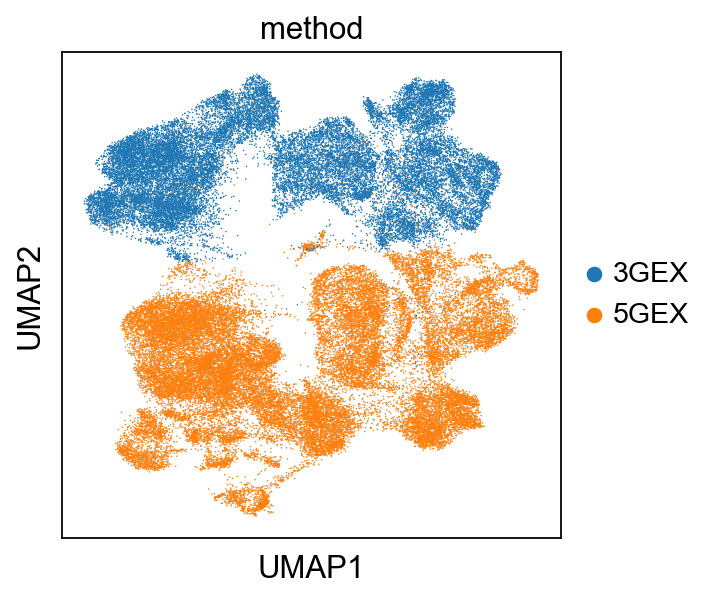

In [25]:
sc.pl.umap(pan_immune_bcells, use_raw=False, color=['method'])
#sc.pl.umap(pan_immune_bcells_harm, color=['method'])

In [26]:
batcheffects = ['predicted_doublets','Sort_id','pct_counts_mt','organ','celltype_annotation','sex','method','age']

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


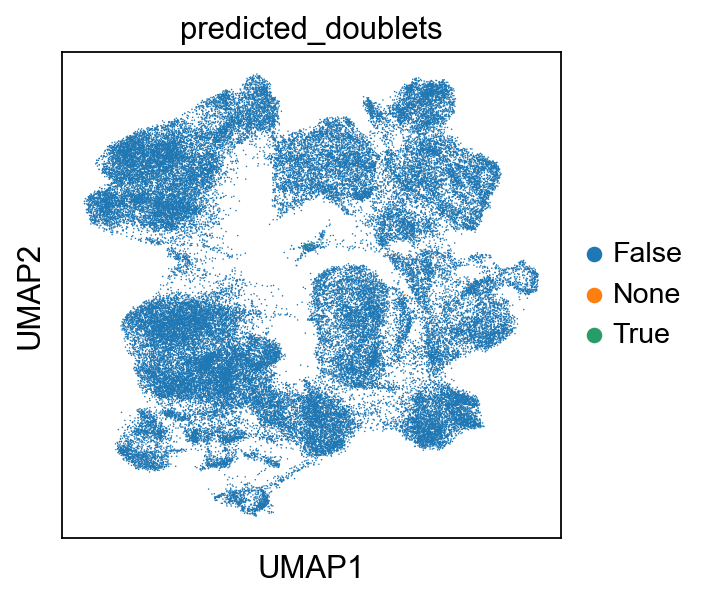

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


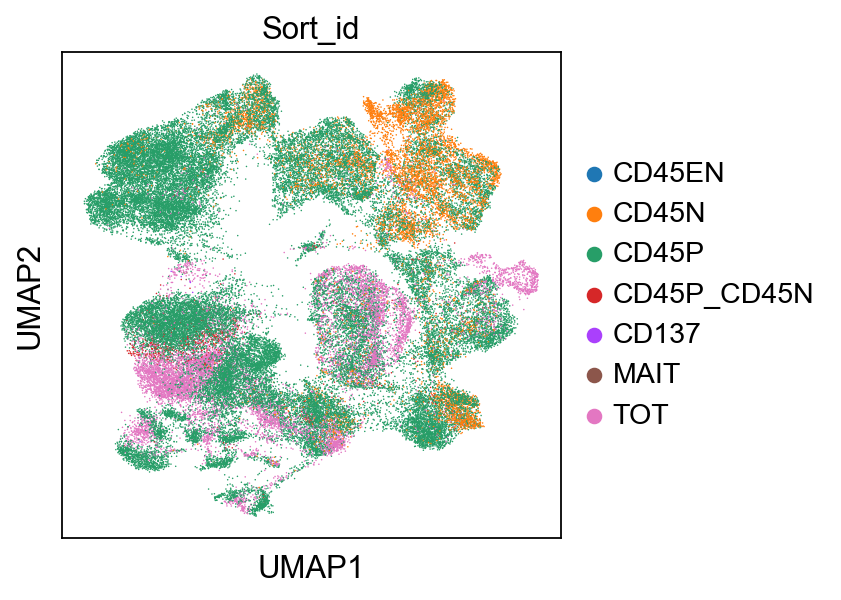

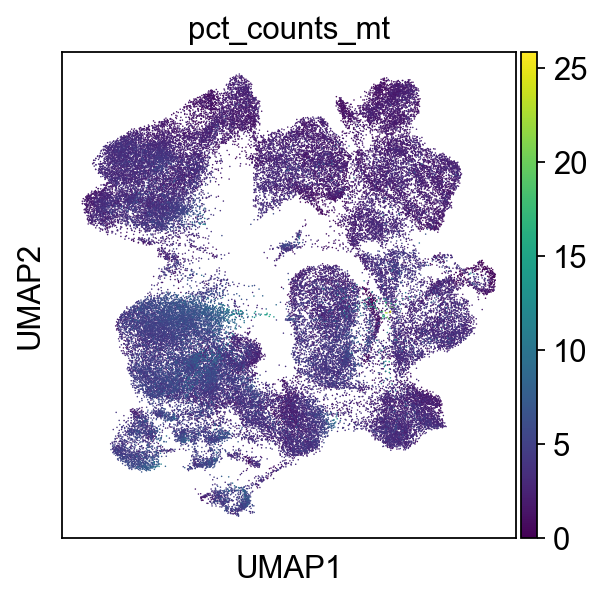

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


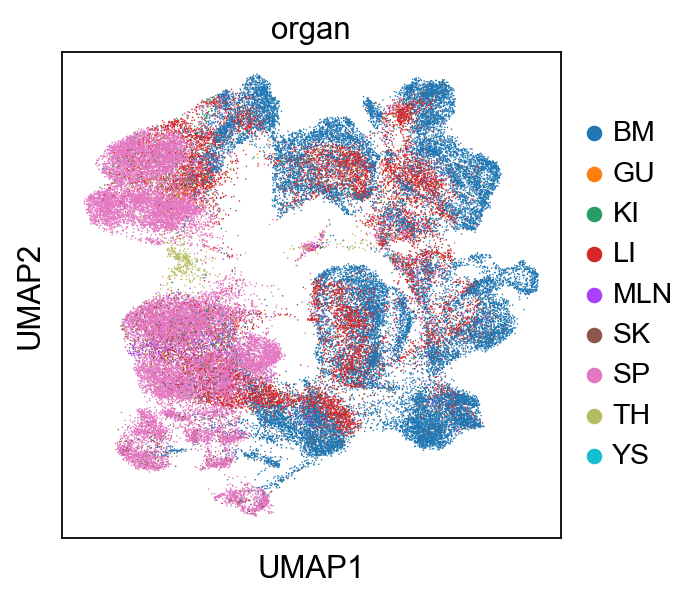

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


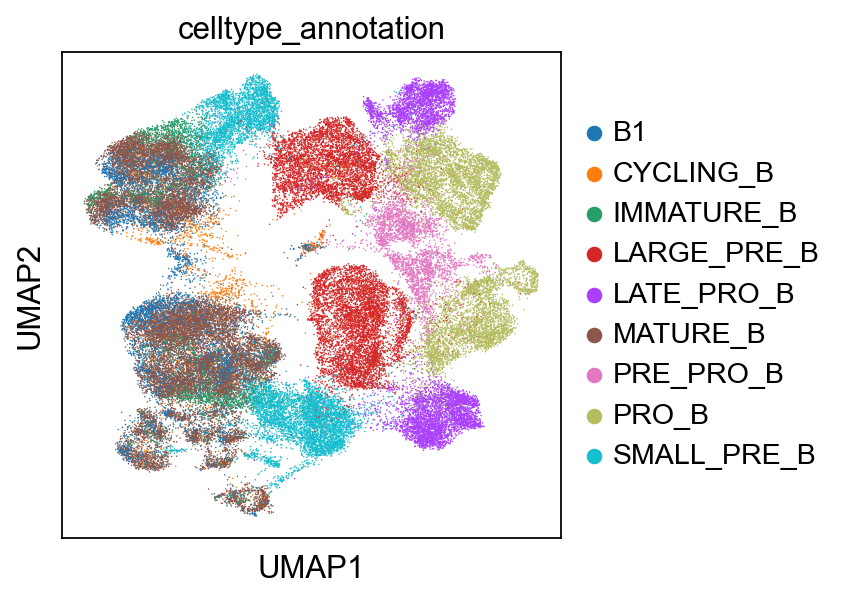

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


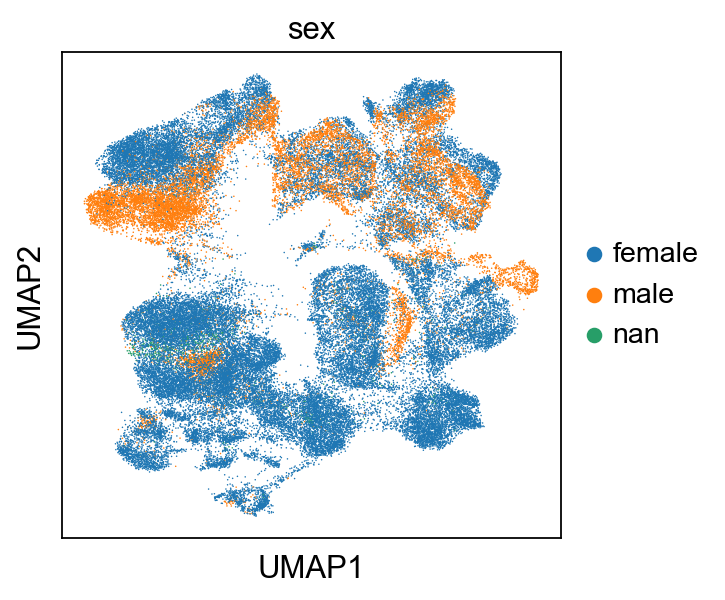

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


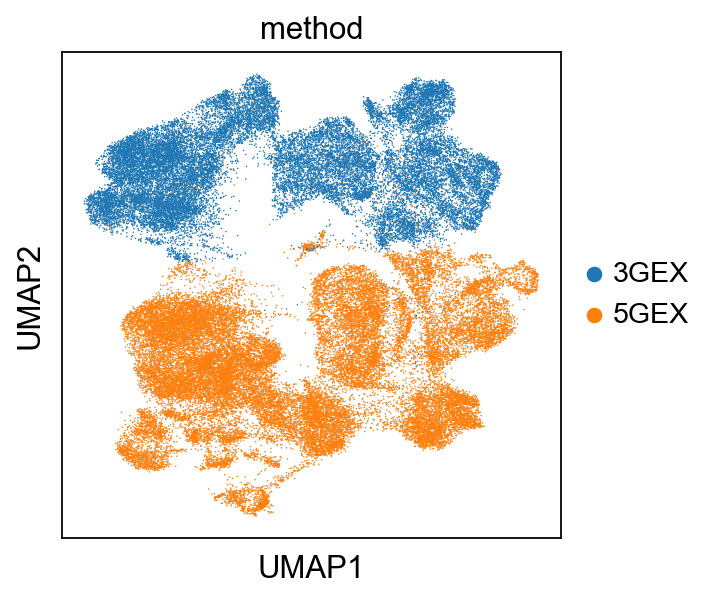

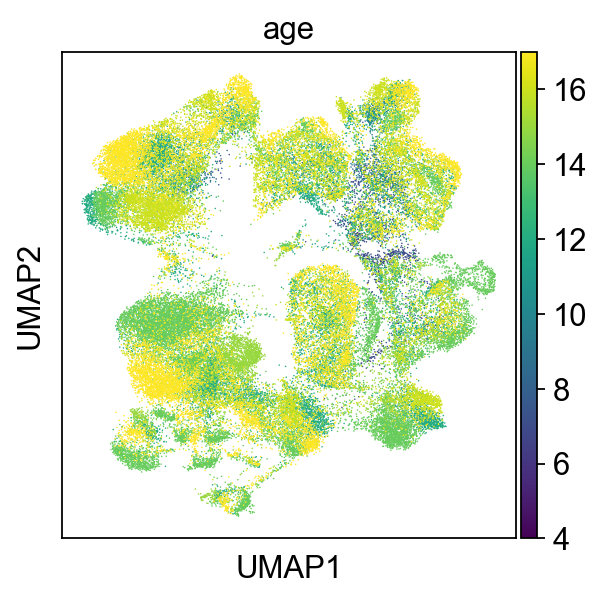

In [27]:
for x in batcheffects:
    sc.pl.umap(pan_immune_bcells, color=[x], use_raw=False, save = '_' + x + '_be_b1.pdf')


# Naming system: type of graph(umap), column from data (predicted_doublets), why the graph exists(to test for batch effects(be)), the file it is from(b1), and the file format (pdf).
# harmony attributes to post-harmony application

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:364: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


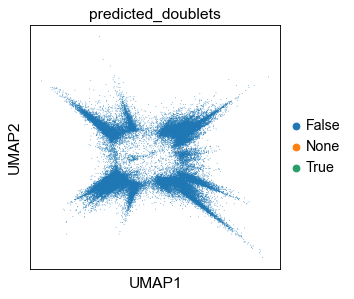

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:364: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


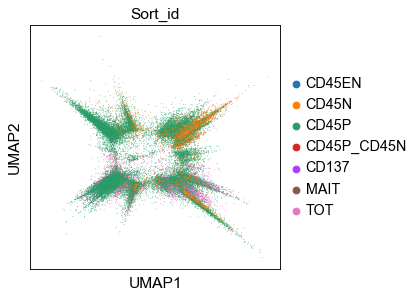

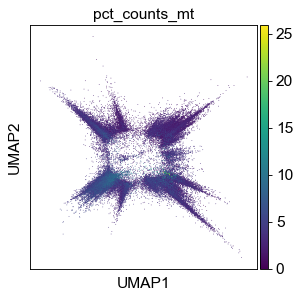

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:364: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


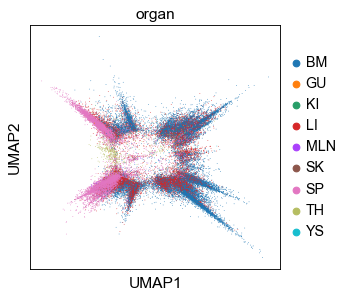

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:364: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


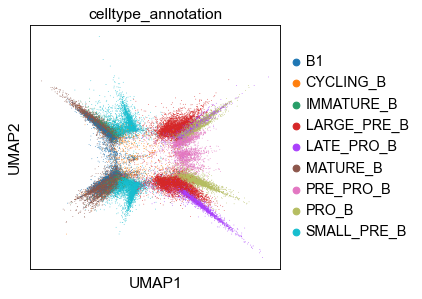

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:364: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


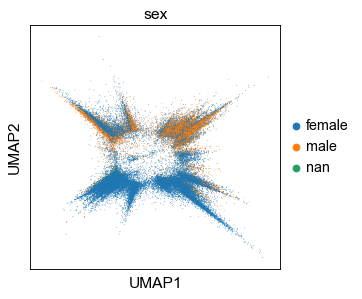

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:364: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


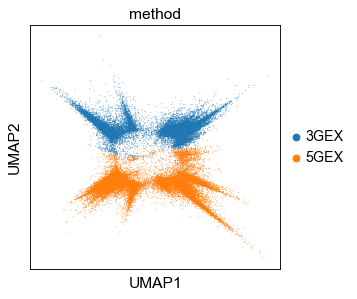

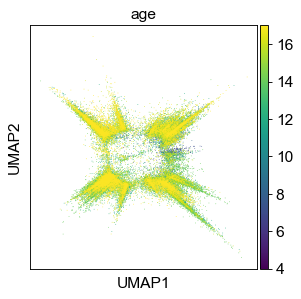

In [182]:
for x in batcheffects:
    sc.pl.umap(pan_immune_bcells_harm, color=[x], use_raw=False, save = '_' + x + '_harmony_b1.pdf')
# the harmony pdf documents

In [183]:
sc.tl.leiden(pan_immune_bcells)


C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:364: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


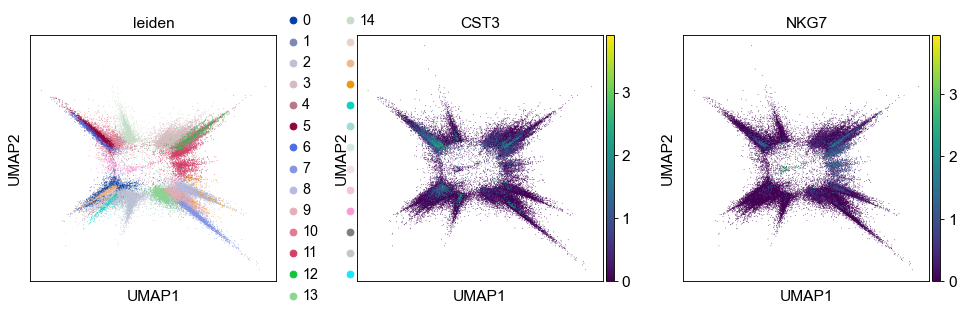

In [184]:
sc.pl.umap(pan_immune_bcells, color=['leiden', 'CST3', 'NKG7'])


In [185]:
#got to decide on how to batch correct.
sc.external.pp.bbknn

<function scanpy.external.pp._bbknn.bbknn(adata: anndata._core.anndata.AnnData, batch_key: str = 'batch', approx: bool = True, metric: Union[str, ForwardRef('sklearn.neighbors.DistanceMetric')] = 'angular', copy: bool = False, *, n_pcs: int = 50, trim: Optional[int] = None, n_trees: int = 10, use_faiss: bool = True, set_op_mix_ratio: float = 1.0, local_connectivity: int = 1, **kwargs) -> anndata._core.anndata.AnnData>

In [186]:

#BBKNN ATTEMPT: the attempt failed but antony gave some ideas: are there any NaN in your neighbours, right package versions, 

#%%time
#sc.external.pp.bbknn(pan_immune_bcells, batch_key='method')


#import bbknn

#bbknn.bbknn(pan_immune_bcells,batch_key='method')

#sc.tl.umap(pan_immune_bcells)

#sc.pl.umap(pan_immune_bcells, color=['method', 'celltype_annotation'])

## End of pre-processing

In [187]:
sc.tl.rank_genes_groups(pan_immune_bcells, 'leiden', method='t-test')
sc.pl.rank_genes_groups(pan_immune_bcells, n_genes=25, sharey=False)

C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\tools\_rank_genes_groups.py:393: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\tools\_rank_genes_groups.py:395: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
C:\Users\sambe\anaconda3\envs\research23\lib\site-packages\scanpy\tools\_rank_genes_groups.py:398: PerformanceWarning: Da

In [ ]:
sc.settings.verbosity = 2  # reduce the verbosity


In [ ]:
pan_immune_bcells = pan_immune_bcells.copy()

In [ ]:
sc.tl.rank_genes_groups(pan_immune_bcells, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(pan_immune_bcells, n_genes=25, sharey=False)


In [ ]:
sc.tl.rank_genes_groups(pan_immune_bcells, 'leiden', method='logreg')
sc.pl.rank_genes_groups(pan_immune_bcells, n_genes=25, sharey=False)

In [ ]:
marker_genes = ['IL7R', 'CD79A', 'MS4A1', 'CD8A', 'CD8B', 'LYZ', 'CD14',
                'LGALS3', 'S100A8', 'GNLY', 'NKG7', 'KLRB1',
                'FCGR3A', 'MS4A7', 'FCER1A', 'CST3', 'PPBP']

In [ ]:
sc.tl.rank_genes_groups(pan_immune_bcells, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(pan_immune_bcells, n_genes=25, sharey=False)

In [ ]:
os.getcwd()

In [ ]:
pan_immune_bcells.write(writes + 'pbmc3k.h5ad')

In [ ]:
adata = sc.read(('C:\\Users\\sambe\\OneDrive - Newcastle University\\Research projects\\python\\write\\pbmc3k.h5ad'))


In [ ]:
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(30)


In [ ]:
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals']}).head(5)

In [ ]:
adata.uns['log1p']["base"] = None
#https://github.com/scverse/scanpy/issues/2239

In [ ]:
sc.tl.rank_genes_groups(adata, 'leiden', groups=['0'], reference='1', method='wilcoxon')
sc.pl.rank_genes_groups(adata, groups=['0'], n_genes=20)

In [ ]:
sc.pl.rank_genes_groups_violin(adata, groups='0', n_genes=8)

In [ ]:
adata = sc.read(writes + 'pbmc3k.h5ad')
sc.pl.rank_genes_groups_violin(adata, groups='0', n_genes=8)

In [ ]:
sc.pl.violin(adata, ['CST3', 'NKG7', 'PPBP', ], groupby='leiden')


In [ ]:
new_cluster_names = [
    'CD4 T', 'CD14 Monocytes',
    'B', 'CD8 T',
    'NK', 'FCGR3A Monocytes',
    'Dendritic', 'Megakaryocytes']
adata.rename_categories('leiden', new_cluster_names)
# here it all falls down as the data does not match slightly, the road has come to an end.